# RQ12 — Shortcut-Resistant Dataset Design

## Research question

> Does the Dataset v1 collection and grouping policy prevent the new 10-candidate ranking formulation from learning candidate-order, repeat or password shortcuts?

RQ11 established that the correct physical decision unit is one complete 10-candidate scan. That reformulation removes the need for an absolute threshold, but it creates a new validity requirement: the model must not obtain the answer from how the scan was collected.

RQ12 therefore audits **metadata only**. No acoustic feature is used.

### Dataset v1 structure

- seven password batches: B01–B07;
- W1, W2 and W4;
- CW and CCW;
- ten start-position profiles per wheel and password;
- A/B repeats;
- ten one-digit candidates per decision.

The intended design rules are:

1. one password per batch;
2. randomised / balanced start positions;
3. balanced true candidate ordinal;
4. complete 10-candidate decisions;
5. paired CW/CCW collection;
6. paired A/B repeats;
7. password-level grouped evaluation.

### Why grouping matters

A/B repeats intentionally reproduce the same candidate order for repeatability measurement. That is useful experimentally but dangerous statistically: if A is placed in training and B in test, a model or lookup can memorise the answer from profile/order metadata.

Likewise, within one password batch the true physical digit is fixed for each wheel. If decisions from the same password are split across training and test, `password × wheel × digit` can become a perfect label shortcut.

RQ12 therefore asks two questions:

- Are positional/order variables actually balanced?
- Do the prescribed grouped splits remove the exact metadata reuse that would otherwise leak the answer?

## 1. Load the preserved B01–B07 decision manifest

In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount(
    "/content/drive"
)

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

PROJECT_ROOT = (
    MYDRIVE
    / "Padlock_Reproduction_v1"
)

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p
        for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the completed RQ7 candidate manifest."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_manifest.csv"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "12_RQ12_Shortcut_Resistant_Dataset"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

assert len(
    manifest
) == 8400

assert manifest[
    "decision_uid"
].nunique() == 840

assert manifest[
    "profile_id"
].nunique() == 210

assert manifest[
    "batch"
].nunique() == 7

assert manifest.groupby(
    "decision_uid"
).size().eq(10).all()

assert manifest.groupby(
    "decision_uid"
)[
    "y"
].sum().eq(1).all()

print(
    "Passwords:",
    manifest[
        "batch"
    ].nunique(),
)

print(
    "Profiles:",
    manifest[
        "profile_id"
    ].nunique(),
)

print(
    "Decisions:",
    manifest[
        "decision_uid"
    ].nunique(),
)

print(
    "Candidates:",
    len(
        manifest
    ),
)

Mounted at /content/drive
Passwords: 7
Profiles: 210
Decisions: 840
Candidates: 8400


## 2. Reconstruct one row per complete decision

In [2]:
truth_rows = (
    manifest.loc[
        manifest[
            "y"
        ]
        == 1,
        [
            "decision_uid",
            "candidate_ordinal",
            "to_digit",
            "true_digit",
        ],
    ]
    .rename(
        columns={
            "candidate_ordinal": (
                "true_ordinal"
            ),
            "to_digit": (
                "true_to_digit"
            ),
        }
    )
)


decision = (
    manifest.groupby(
        "decision_uid",
        sort=False,
    )
    .agg(
        batch=(
            "batch",
            "first",
        ),
        password=(
            "password",
            "first",
        ),
        profile_id=(
            "profile_id",
            "first",
        ),
        wheel=(
            "wheel",
            "first",
        ),
        direction=(
            "direction",
            "first",
        ),
        repeat_id=(
            "repeat_id",
            "first",
        ),
        first_to_digit=(
            "to_digit",
            "first",
        ),
        candidate_digits=(
            "to_digit",
            lambda x: tuple(
                x.astype(
                    int
                ).tolist()
            ),
        ),
    )
    .reset_index()
    .merge(
        truth_rows[
            [
                "decision_uid",
                "true_ordinal",
                "true_to_digit",
                "true_digit",
            ]
        ],
        on="decision_uid",
        how="left",
        validate="one_to_one",
    )
)

assert len(
    decision
) == 840

display(
    decision.head()
)

,decision_uid,batch,password,profile_id,wheel,direction,repeat_id,first_to_digit,candidate_digits,true_ordinal,true_to_digit,true_digit
0,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_2085,2085,B01_W1_P01,1,CCW,A,1,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 0)",2,2,2
1,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_2085,2085,B01_W1_P01,1,CCW,B,1,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 0)",2,2,2
2,B01_2085/B01_W1_P01_DSV1_MP2085_CW_A,B01_2085,2085,B01_W1_P01,1,CW,A,9,"(9, 8, 7, 6, 5, 4, 3, 2, 1, 0)",8,2,2
3,B01_2085/B01_W1_P01_DSV1_MP2085_CW_B,B01_2085,2085,B01_W1_P01,1,CW,B,9,"(9, 8, 7, 6, 5, 4, 3, 2, 1, 0)",8,2,2
4,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_2085,2085,B01_W1_P02,1,CCW,A,0,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",3,2,2


## 3. Structural balance and completeness

In [3]:
batch_balance = (
    decision.groupby(
        "batch"
    )
    .agg(
        password=(
            "password",
            "first",
        ),
        n_decisions=(
            "decision_uid",
            "size",
        ),
        n_profiles=(
            "profile_id",
            "nunique",
        ),
        n_wheels=(
            "wheel",
            "nunique",
        ),
        n_directions=(
            "direction",
            "nunique",
        ),
        n_repeats=(
            "repeat_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(
    batch_balance
)

assert batch_balance[
    "n_decisions"
].eq(120).all()

assert batch_balance[
    "n_profiles"
].eq(30).all()

,batch,password,n_decisions,n_profiles,n_wheels,n_directions,n_repeats
0,B01_2085,2085,120,30,3,2,2
1,B02_4369,4369,120,30,3,2,2
2,B03_5720,5720,120,30,3,2,2
3,B04_6893,6893,120,30,3,2,2
4,B05_7246,7246,120,30,3,2,2
5,B06_8451,8451,120,30,3,2,2
6,B07_9638,9638,120,30,3,2,2


In [4]:
ordinal_balance = (
    decision.groupby(
        [
            "batch",
            "password",
            "true_ordinal",
        ]
    )
    .size()
    .rename(
        "n_true_decisions"
    )
    .reset_index()
)

ordinal_matrix = (
    ordinal_balance.pivot(
        index="password",
        columns="true_ordinal",
        values="n_true_decisions",
    )
    .sort_index()
)

assert np.all(
    ordinal_matrix.to_numpy()
    == 12
)

print(
    "Overall true ordinal counts:"
)

display(
    decision[
        "true_ordinal"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n_true"
    )
    .to_frame()
)

print(
    "Every ordinal is true in",
    int(
        (
            decision[
                "true_ordinal"
            ]
            == 1
        ).sum()
    ),
    "of 840 decisions."
)

Overall true ordinal counts:


,n_true
true_ordinal,
1,84
2,84
3,84
4,84
5,84
6,84
7,84
8,84
9,84


Every ordinal is true in 84 of 840 decisions.


In [5]:
start_balance = (
    decision.groupby(
        [
            "batch",
            "wheel",
            "direction",
            "first_to_digit",
        ]
    )
    .size()
    .rename(
        "n_decisions"
    )
    .reset_index()
)

assert start_balance[
    "n_decisions"
].eq(2).all()


domain_balance = (
    decision.groupby(
        [
            "batch",
            "wheel",
            "direction",
        ]
    )
    .agg(
        n_decisions=(
            "decision_uid",
            "size",
        ),
        n_profiles=(
            "profile_id",
            "nunique",
        ),
        n_repeats=(
            "repeat_id",
            "nunique",
        ),
    )
    .reset_index()
)

assert domain_balance[
    "n_decisions"
].eq(20).all()

assert domain_balance[
    "n_profiles"
].eq(10).all()

assert domain_balance[
    "n_repeats"
].eq(2).all()


profile_pairing = (
    decision.groupby(
        [
            "batch",
            "profile_id",
            "wheel",
        ]
    )
    .agg(
        n_decisions=(
            "decision_uid",
            "size",
        ),
        n_directions=(
            "direction",
            "nunique",
        ),
        n_repeats=(
            "repeat_id",
            "nunique",
        ),
    )
    .reset_index()
)

assert len(
    profile_pairing
) == 210

assert profile_pairing[
    "n_decisions"
].eq(4).all()

assert profile_pairing[
    "n_directions"
].eq(2).all()

assert profile_pairing[
    "n_repeats"
].eq(2).all()


candidate_coverage = (
    manifest.groupby(
        "decision_uid"
    )
    .agg(
        n_candidates=(
            "to_digit",
            "size",
        ),
        n_unique_digits=(
            "to_digit",
            "nunique",
        ),
        n_true=(
            "y",
            "sum",
        ),
    )
    .reset_index()
)

candidate_coverage[
    "complete_0_to_9"
] = (
    manifest.groupby(
        "decision_uid"
    )[
        "to_digit"
    ]
    .apply(
        lambda x: sorted(
            x.astype(
                int
            ).tolist()
        )
        == list(
            range(10)
        )
    )
    .to_numpy()
)

assert candidate_coverage[
    "complete_0_to_9"
].all()

print(
    "Complete decisions:",
    int(
        candidate_coverage[
            "complete_0_to_9"
        ].sum()
    ),
    "/",
    len(
        candidate_coverage
    ),
)

print(
    "Profiles with CW/CCW and A/B:",
    len(
        profile_pairing
    ),
    "/",
    len(
        profile_pairing
    ),
)

Complete decisions: 840 / 840
Profiles with CW/CCW and A/B: 210 / 210


## 4. A/B repeat leakage audit

A and B deliberately repeat the same start profile and direction. We therefore verify whether their candidate order and true ordinal are identical.

If they are, A and B must never be treated as independent train/test observations.

In [6]:
repeat_pair_rows = []

for (
    key,
    group,
) in decision.groupby(
    [
        "batch",
        "profile_id",
        "wheel",
        "direction",
    ],
    sort=False,
):
    by_repeat = group.set_index(
        "repeat_id"
    )

    has_pair = (
        len(
            group
        )
        == 2
        and set(
            group[
                "repeat_id"
            ]
        )
        == {
            "A",
            "B",
        }
    )

    if has_pair:
        same_order = (
            by_repeat.loc[
                "A",
                "candidate_digits",
            ]
            ==
            by_repeat.loc[
                "B",
                "candidate_digits",
            ]
        )

        same_true_ordinal = (
            int(
                by_repeat.loc[
                    "A",
                    "true_ordinal",
                ]
            )
            ==
            int(
                by_repeat.loc[
                    "B",
                    "true_ordinal",
                ]
            )
        )

    else:
        same_order = False
        same_true_ordinal = False

    repeat_pair_rows.append({
        "batch": key[
            0
        ],
        "profile_id": key[
            1
        ],
        "wheel": key[
            2
        ],
        "direction": key[
            3
        ],
        "has_A_B": (
            has_pair
        ),
        "same_candidate_order": (
            same_order
        ),
        "same_true_ordinal": (
            same_true_ordinal
        ),
    })


repeat_pairing = pd.DataFrame(
    repeat_pair_rows
)

assert len(
    repeat_pairing
) == 420

assert repeat_pairing[
    [
        "has_A_B",
        "same_candidate_order",
        "same_true_ordinal",
    ]
].all().all()

print(
    "A/B pairs with identical candidate order:",
    int(
        repeat_pairing[
            "same_candidate_order"
        ].sum()
    ),
    "/",
    len(
        repeat_pairing
    ),
)

A/B pairs with identical candidate order: 420 / 420


## 5. Metadata-only shortcut stress tests

In [7]:
# Deliberately leaky test 1:
# learn A and test B using exact
# profile + direction + ordinal identity.

A = manifest[
    manifest[
        "repeat_id"
    ]
    == "A"
].copy()

B = manifest[
    manifest[
        "repeat_id"
    ]
    == "B"
].copy()


repeat_key = [
    "batch",
    "profile_id",
    "wheel",
    "direction",
    "candidate_ordinal",
]

repeat_lookup = (
    A[
        repeat_key
        + [
            "y"
        ]
    ]
    .rename(
        columns={
            "y": (
                "lookup_score"
            ),
        }
    )
)

B_repeat = B.merge(
    repeat_lookup,
    on=repeat_key,
    how="left",
    validate="one_to_one",
)

assert B_repeat[
    "lookup_score"
].notna().all()

correct = []

for (
    decision_uid,
    group,
) in B_repeat.groupby(
    "decision_uid",
    sort=False,
):
    predicted = group.loc[
        group[
            "lookup_score"
        ].idxmax()
    ]

    correct.append(
        int(
            predicted[
                "y"
            ]
            == 1
        )
    )


repeat_lookup_top1 = float(
    np.mean(
        correct
    )
)

print(
    "Leaky A→B repeat-position lookup Top-1:",
    f"{100 * repeat_lookup_top1:.1f}%",
)

Leaky A→B repeat-position lookup Top-1: 100.0%


In [8]:
# Deliberately leaky test 2:
# within the same password, memorise
# batch + wheel + physical digit from A
# and apply it to B.

password_key = [
    "batch",
    "wheel",
    "to_digit",
]

password_lookup = (
    A.groupby(
        password_key,
        as_index=False,
    )[
        "y"
    ]
    .mean()
    .rename(
        columns={
            "y": (
                "lookup_score"
            ),
        }
    )
)

B_password = B.merge(
    password_lookup,
    on=password_key,
    how="left",
    validate="many_to_one",
)

correct = []

for (
    decision_uid,
    group,
) in B_password.groupby(
    "decision_uid",
    sort=False,
):
    winners = group[
        group[
            "lookup_score"
        ]
        == group[
            "lookup_score"
        ].max()
    ]

    assert len(
        winners
    ) == 1

    correct.append(
        int(
            winners.iloc[
                0
            ][
                "y"
            ]
            == 1
        )
    )


password_lookup_top1 = float(
    np.mean(
        correct
    )
)

print(
    "Leaky within-password digit lookup Top-1:",
    f"{100 * password_lookup_top1:.1f}%",
)

Leaky within-password digit lookup Top-1: 100.0%


In [9]:
# Correctly grouped controls.

ordinal_lopo_rows = []

for heldout_batch in sorted(
    decision[
        "batch"
    ].unique()
):
    train = decision[
        decision[
            "batch"
        ]
        != heldout_batch
    ]

    test = decision[
        decision[
            "batch"
        ]
        == heldout_batch
    ]

    rate_by_ordinal = (
        train[
            "true_ordinal"
        ]
        .value_counts(
            normalize=True
        )
        .reindex(
            range(
                1,
                11,
            ),
            fill_value=0.0,
        )
    )

    assert np.allclose(
        rate_by_ordinal.to_numpy(),
        0.10,
    )

    chosen_ordinal = int(
        rate_by_ordinal.index[
            np.argmax(
                rate_by_ordinal.to_numpy()
            )
        ]
    )

    ordinal_lopo_rows.append({
        "heldout_batch": heldout_batch,
        "password": str(
            test[
                "password"
            ].iloc[
                0
            ]
        ),
        "top1": float(
            np.mean(
                test[
                    "true_ordinal"
                ]
                == chosen_ordinal
            )
        ),
    })


ordinal_lopo = pd.DataFrame(
    ordinal_lopo_rows
)

assert np.allclose(
    ordinal_lopo[
        "top1"
    ],
    0.10,
)


digit_lopo_rows = []

for heldout_batch in sorted(
    manifest[
        "batch"
    ].unique()
):
    train = manifest[
        manifest[
            "batch"
        ]
        != heldout_batch
    ]

    test = manifest[
        manifest[
            "batch"
        ]
        == heldout_batch
    ].copy()

    score_table = (
        train.groupby(
            [
                "wheel",
                "to_digit",
            ],
            as_index=False,
        )[
            "y"
        ]
        .mean()
        .rename(
            columns={
                "y": (
                    "lookup_score"
                ),
            }
        )
    )

    test = test.merge(
        score_table,
        on=[
            "wheel",
            "to_digit",
        ],
        how="left",
        validate="many_to_one",
    )

    correct = []

    for (
        decision_uid,
        group,
    ) in test.groupby(
        "decision_uid",
        sort=False,
    ):
        ranked = group.sort_values(
            [
                "lookup_score",
                "to_digit",
            ],
            ascending=[
                False,
                True,
            ],
        )

        correct.append(
            int(
                ranked.iloc[
                    0
                ][
                    "y"
                ]
                == 1
            )
        )

    digit_lopo_rows.append({
        "heldout_batch": heldout_batch,
        "password": str(
            test[
                "password"
            ].iloc[
                0
            ]
        ),
        "top1": float(
            np.mean(
                correct
            )
        ),
    })


digit_lopo = pd.DataFrame(
    digit_lopo_rows
)

assert np.allclose(
    digit_lopo[
        "top1"
    ],
    0.0,
)

print(
    "Candidate ordinal only, password LOPO:",
    f"{100 * ordinal_lopo['top1'].mean():.1f}%",
)

print(
    "Forbidden wheel+digit lookup, password LOPO:",
    f"{100 * digit_lopo['top1'].mean():.1f}%",
)

Candidate ordinal only, password LOPO: 10.0%
Forbidden wheel+digit lookup, password LOPO: 0.0%


These diagnostic lookups are not proposed models.

They demonstrate the validity problem directly:

- if A and B are split, repeat-position metadata reproduces the answer;
- if the same password appears on both sides of a split, password × wheel × digit reproduces the answer;
- with the intended password grouping, candidate ordinal is exactly chance;
- even the forbidden physical digit does not explain held-out-password ranking because each wheel's held-out true digit is new relative to the other six training passwords.

## 6. Main figures

In [10]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

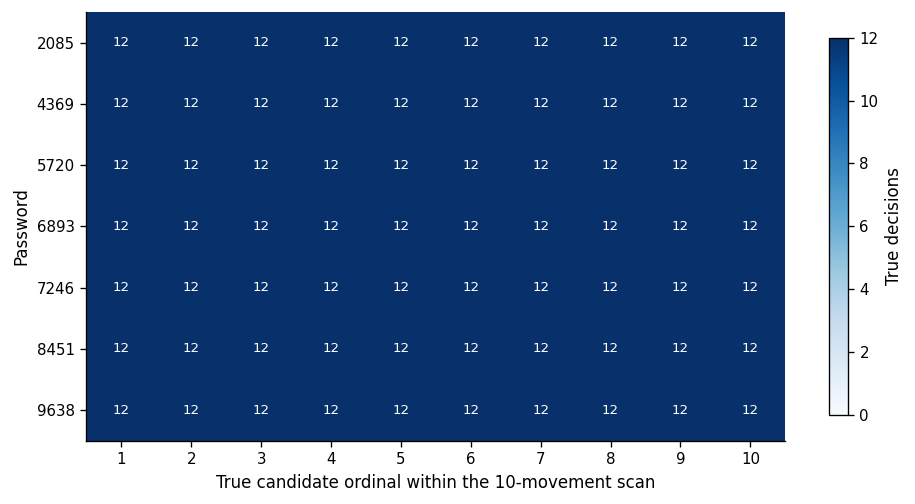

In [11]:
# Figure 1 — the true candidate is perfectly balanced across ordinal positions.

fig, ax = plt.subplots(
    figsize=(
        8.2,
        4.3,
    )
)

image = ax.imshow(
    ordinal_matrix.to_numpy(),
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=12,
)

ax.set_xticks(
    np.arange(
        10
    )
)

ax.set_xticklabels(
    np.arange(
        1,
        11,
    )
)

ax.set_yticks(
    np.arange(
        len(
            ordinal_matrix.index
        )
    )
)

ax.set_yticklabels(
    ordinal_matrix.index.astype(
        str
    )
)

ax.set_xlabel(
    "True candidate ordinal within the 10-movement scan"
)

ax.set_ylabel(
    "Password"
)

for i in range(
    ordinal_matrix.shape[
        0
    ]
):
    for j in range(
        ordinal_matrix.shape[
            1
        ]
    ):
        ax.text(
            j,
            i,
            f"{int(ordinal_matrix.iloc[i, j])}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )

cbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.88,
)

cbar.set_label(
    "True decisions"
)

fig.tight_layout()

save_figure(
    fig,
    "RQ12_Fig1_true_ordinal_balance",
)

plt.show()

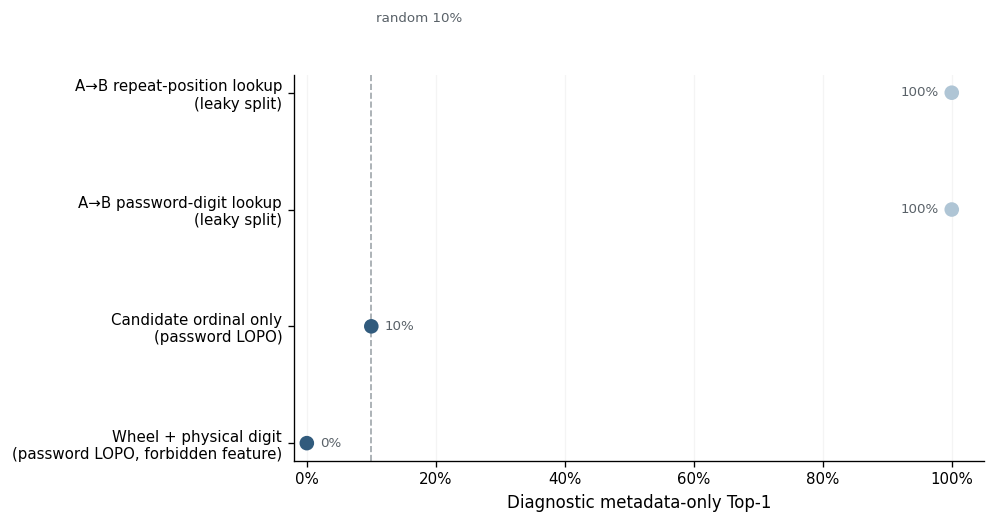

In [12]:
# Figure 2 — diagnostic metadata shortcut stress test.

shortcut_baselines = pd.DataFrame([
    {
        "diagnostic": (
            "A→B repeat-position lookup\n"
            "(leaky split)"
        ),
        "split_type": (
            "Leaky"
        ),
        "top1": (
            repeat_lookup_top1
        ),
    },
    {
        "diagnostic": (
            "A→B password-digit lookup\n"
            "(leaky split)"
        ),
        "split_type": (
            "Leaky"
        ),
        "top1": (
            password_lookup_top1
        ),
    },
    {
        "diagnostic": (
            "Candidate ordinal only\n"
            "(password LOPO)"
        ),
        "split_type": (
            "Grouped"
        ),
        "top1": float(
            ordinal_lopo[
                "top1"
            ].mean()
        ),
    },
    {
        "diagnostic": (
            "Wheel + physical digit\n"
            "(password LOPO, forbidden feature)"
        ),
        "split_type": (
            "Grouped"
        ),
        "top1": float(
            digit_lopo[
                "top1"
            ].mean()
        ),
    },
])


fig, ax = plt.subplots(
    figsize=(
        8.4,
        4.5,
    )
)

y = np.arange(
    len(
        shortcut_baselines
    )
)

colors = [
    LIGHT_BLUE
    if split_type
    == "Leaky"
    else DARK_BLUE
    for split_type
    in shortcut_baselines[
        "split_type"
    ]
]

ax.scatter(
    100
    * shortcut_baselines[
        "top1"
    ],
    y,
    s=60,
    color=colors,
    zorder=3,
)

for (
    yi,
    row,
) in shortcut_baselines.iterrows():
    value = (
        100
        * row[
            "top1"
        ]
    )

    offset = (
        -8
        if value
        >= 95
        else 8
    )

    ha = (
        "right"
        if value
        >= 95
        else "left"
    )

    ax.annotate(
        f"{value:.0f}%",
        xy=(
            value,
            yi,
        ),
        xytext=(
            offset,
            0,
        ),
        textcoords="offset points",
        ha=ha,
        va="center",
        fontsize=8,
        color=DARK_GREY,
    )


ax.axvline(
    10,
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
)

ax.text(
    10.8,
    -0.58,
    "random 10%",
    fontsize=8,
    color=DARK_GREY,
    va="bottom",
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    shortcut_baselines[
        "diagnostic"
    ]
)

ax.invert_yaxis()

ax.set_xlim(
    -2,
    105,
)

ax.set_xlabel(
    "Diagnostic metadata-only Top-1"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ12_Fig2_shortcut_stress_test",
)

plt.show()

## 7. Frozen grouping contract

In [13]:
grouping_contract = pd.DataFrame([
    {
        "level": "Candidate",
        "key": "run_id / row_id",
        "contains": (
            "One one-digit movement"
        ),
        "rule": (
            "Never split candidates "
            "from the same decision."
        ),
    },
    {
        "level": "Decision",
        "key": "decision_uid",
        "contains": (
            "10 candidates covering digits 0-9"
        ),
        "rule": (
            "Atomic ranking unit; "
            "exactly one true candidate."
        ),
    },
    {
        "level": "Repeat pair",
        "key": (
            "batch + profile_id "
            "+ wheel + direction"
        ),
        "contains": "A and B",
        "rule": (
            "Keep A/B together "
            "in validation splits."
        ),
    },
    {
        "level": "Profile",
        "key": (
            "batch + profile_id "
            "+ wheel"
        ),
        "contains": (
            "CW/CCW × A/B = 4 decisions"
        ),
        "rule": (
            "Keep the complete start-position "
            "profile together."
        ),
    },
    {
        "level": "Password batch",
        "key": (
            "batch / password"
        ),
        "contains": (
            "3 wheels × 2 directions × "
            "10 profiles × 2 repeats"
        ),
        "rule": (
            "Primary evaluation group: "
            "hold out the entire password."
        ),
    },
])

display(
    grouping_contract
)


forbidden_inputs = pd.DataFrame([
    {
        "field": (
            "batch / password"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": (
            "profile_id"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": (
            "repeat_id"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": (
            "candidate_ordinal"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": (
            "to_digit / physical candidate digit"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": (
            "run / decision identifiers"
        ),
        "status": (
            "Forbidden model input"
        ),
    },
    {
        "field": "wheel",
        "status": (
            "Allowed known domain"
        ),
    },
    {
        "field": "direction",
        "status": (
            "Allowed known domain"
        ),
    },
])

display(
    forbidden_inputs
)

,level,key,contains,rule
0,Candidate,run_id / row_id,One one-digit movement,Never split candidates from the same decision.
1,Decision,decision_uid,10 candidates covering digits 0-9,Atomic ranking unit; exactly one true candidate.
2,Repeat pair,batch + profile_id + wheel + direction,A and B,Keep A/B together in validation splits.
3,Profile,batch + profile_id + wheel,CW/CCW × A/B = 4 decisions,Keep the complete start-position profile toget...
4,Password batch,batch / password,3 wheels × 2 directions × 10 profiles × 2 repeats,Primary evaluation group: hold out the entire ...


,field,status
0,batch / password,Forbidden model input
1,profile_id,Forbidden model input
2,repeat_id,Forbidden model input
3,candidate_ordinal,Forbidden model input
4,to_digit / physical candidate digit,Forbidden model input
5,run / decision identifiers,Forbidden model input
6,wheel,Allowed known domain
7,direction,Allowed known domain


## 8. Limitation

Dataset v1 contains seven password batches. For each wheel, those seven passwords provide **seven distinct positive true-digit values**, not all ten possible digits.

That is sufficient to make held-out-password digit memorisation difficult and to test generalisation across multiple true digits, but it is not exhaustive 10-digit positive coverage.

RQ12 therefore establishes that the identified collection shortcuts are controlled; it does not claim that every possible true digit has equal positive coverage across passwords.

## 9. Tables and result record

In [14]:
# Save all audit tables.

decision_export = decision.copy()

decision_export[
    "candidate_digits"
] = decision_export[
    "candidate_digits"
].map(
    lambda x: ",".join(
        map(
            str,
            x,
        )
    )
)

decision_export.to_csv(
    RESULT_DIR
    / "RQ12_decision_manifest.csv",
    index=False,
)

batch_balance.to_csv(
    RESULT_DIR
    / "RQ12_batch_balance.csv",
    index=False,
)


domain_balance.to_csv(
    RESULT_DIR
    / "RQ12_domain_balance.csv",
    index=False,
)

ordinal_balance.to_csv(
    RESULT_DIR
    / "RQ12_true_ordinal_balance.csv",
    index=False,
)

start_balance.to_csv(
    RESULT_DIR
    / "RQ12_start_digit_balance.csv",
    index=False,
)

profile_pairing.to_csv(
    RESULT_DIR
    / "RQ12_profile_pairing.csv",
    index=False,
)

repeat_pairing.to_csv(
    RESULT_DIR
    / "RQ12_repeat_pairing.csv",
    index=False,
)

candidate_coverage.to_csv(
    RESULT_DIR
    / "RQ12_decision_completeness.csv",
    index=False,
)

ordinal_lopo.to_csv(
    RESULT_DIR
    / "RQ12_ordinal_only_LOPO.csv",
    index=False,
)

digit_lopo.to_csv(
    RESULT_DIR
    / "RQ12_forbidden_digit_LOPO.csv",
    index=False,
)

shortcut_baselines.to_csv(
    RESULT_DIR
    / "RQ12_shortcut_baselines.csv",
    index=False,
)


leakage_stress = pd.DataFrame([
    {
        "shortcut": (
            "Repeat-position key "
            "(profile + direction + ordinal)"
        ),
        "leaky_split": (
            "Train A → test B"
        ),
        "leaky_key_reuse": 1.0,
        "leaky_top1": (
            repeat_lookup_top1
        ),
        "proper_split": (
            "Leave password/batch out"
        ),
        "proper_key_reuse": 0.0,
        "control_rule": (
            "Keep A/B and profile together"
        ),
    },
    {
        "shortcut": (
            "Password-digit key "
            "(batch + wheel + digit)"
        ),
        "leaky_split": (
            "Within-password A → B"
        ),
        "leaky_key_reuse": 1.0,
        "leaky_top1": (
            password_lookup_top1
        ),
        "proper_split": (
            "Leave password/batch out"
        ),
        "proper_key_reuse": 0.0,
        "control_rule": (
            "Hold out the entire password batch"
        ),
    },
])

leakage_stress.to_csv(
    RESULT_DIR
    / "RQ12_leakage_stress.csv",
    index=False,
)

grouping_contract.to_csv(
    RESULT_DIR
    / "RQ12_grouping_contract.csv",
    index=False,
)

forbidden_inputs.to_csv(
    RESULT_DIR
    / "RQ12_model_input_policy.csv",
    index=False,
)


true_digit_coverage = (
    decision[
        [
            "batch",
            "password",
            "wheel",
            "true_digit",
        ]
    ]
    .drop_duplicates()
)

true_digit_coverage.to_csv(
    RESULT_DIR
    / "RQ12_true_digit_coverage.csv",
    index=False,
)


table1 = batch_balance.copy()

table1[
    "Password"
] = table1[
    "password"
].astype(
    str
)

table1 = table1[
    [
        "batch",
        "Password",
        "n_decisions",
        "n_profiles",
        "n_wheels",
        "n_directions",
        "n_repeats",
    ]
].rename(
    columns={
        "batch": "Batch",
        "n_decisions": (
            "Decisions"
        ),
        "n_profiles": (
            "Profiles"
        ),
        "n_wheels": (
            "Wheels"
        ),
        "n_directions": (
            "Directions"
        ),
        "n_repeats": (
            "Repeats"
        ),
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ12_Table1_batch_structure.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ12_Table1_batch_structure.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = pd.DataFrame([
    {
        "Audit": (
            "Complete 10-candidate decisions"
        ),
        "Result": (
            f"{int(candidate_coverage['complete_0_to_9'].sum())}"
            f"/{len(candidate_coverage)}"
        ),
        "Interpretation": "Pass",
    },
    {
        "Audit": (
            "True candidate ordinal balance"
        ),
        "Result": (
            "84/840 at every ordinal "
            "(10.0% each)"
        ),
        "Interpretation": "Pass",
    },
    {
        "Audit": (
            "Start / first-candidate digit balance"
        ),
        "Result": (
            "2 decisions per digit in every "
            "batch × wheel × direction"
        ),
        "Interpretation": "Pass",
    },
    {
        "Audit": (
            "A/B candidate-order pairing"
        ),
        "Result": (
            f"{int(repeat_pairing['same_candidate_order'].sum())}"
            f"/{len(repeat_pairing)} identical"
        ),
        "Interpretation": (
            "Requires grouped splitting"
        ),
    },
    {
        "Audit": (
            "CW/CCW + A/B profile completeness"
        ),
        "Result": (
            f"{len(profile_pairing)}/"
            f"{len(profile_pairing)} profiles "
            "contain 4 decisions"
        ),
        "Interpretation": "Pass",
    },
    {
        "Audit": (
            "Password-level true-digit diversity"
        ),
        "Result": (
            "7 distinct true digits per wheel"
        ),
        "Interpretation": (
            "Good, not full 10-digit coverage"
        ),
    },
])

table2.to_csv(
    RESULT_DIR
    / "RQ12_Table2_shortcut_audit.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ12_Table2_shortcut_audit.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    table2
)

,Batch,Password,Decisions,Profiles,Wheels,Directions,Repeats
0,B01_2085,2085,120,30,3,2,2
1,B02_4369,4369,120,30,3,2,2
2,B03_5720,5720,120,30,3,2,2
3,B04_6893,6893,120,30,3,2,2
4,B05_7246,7246,120,30,3,2,2
5,B06_8451,8451,120,30,3,2,2
6,B07_9638,9638,120,30,3,2,2


,Audit,Result,Interpretation
0,Complete 10-candidate decisions,840/840,Pass
1,True candidate ordinal balance,84/840 at every ordinal (10.0% each),Pass
2,Start / first-candidate digit balance,2 decisions per digit in every batch × wheel ×...,Pass
3,A/B candidate-order pairing,420/420 identical,Requires grouped splitting
4,CW/CCW + A/B profile completeness,210/210 profiles contain 4 decisions,Pass
5,Password-level true-digit diversity,7 distinct true digits per wheel,"Good, not full 10-digit coverage"


In [15]:
conclusion = {
    "research_question": (
        "Does Dataset v1 and its grouping policy prevent the new Digit Scan "
        "ranking formulation from learning collection shortcuts?"
    ),
    "analysis_type": (
        "Metadata-only shortcut-resistance and grouping audit"
    ),
    "dataset": {
        "password_batches": 7,
        "profiles": 210,
        "decisions": 840,
        "candidates": 8400,
        "wheels": [
            1,
            2,
            4,
        ],
        "directions": [
            "CCW",
            "CW",
        ],
        "repeats": [
            "A",
            "B",
        ],
    },
    "passed_audits": {
        "complete_decisions": (
            "840/840 decisions contain exactly ten unique digits 0-9 "
            "and exactly one true candidate."
        ),
        "batch_balance": (
            "Each password batch contains 120 decisions: "
            "3 wheels × 2 directions × 10 profiles × 2 repeats."
        ),
        "candidate_ordinal_balance": (
            "Every candidate ordinal 1-10 is the true position 84/840 times "
            "overall (10.0% each), and 12 times within every password batch."
        ),
        "start_balance": (
            "Within every batch × wheel × direction, each first candidate digit "
            "appears exactly twice (A/B)."
        ),
        "profile_pairing": (
            "All 210 profiles contain both directions and both repeats "
            "(four complete decisions per profile)."
        ),
        "repeat_pairing": (
            "All 420 profile × direction A/B pairs have identical candidate "
            "order and identical true ordinal."
        ),
        "true_digit_diversity": (
            "Each wheel uses seven distinct true digits across the seven password batches."
        ),
    },
    "shortcut_stress_tests": {
        "leaky_A_to_B_repeat_position_lookup_top1": (
            repeat_lookup_top1
        ),
        "leaky_A_to_B_password_digit_lookup_top1": (
            password_lookup_top1
        ),
        "candidate_ordinal_only_password_LOPO_top1": float(
            ordinal_lopo[
                "top1"
            ].mean()
        ),
        "forbidden_wheel_digit_password_LOPO_top1": float(
            digit_lopo[
                "top1"
            ].mean()
        ),
        "interpretation": (
            "If A/B or the same password is allowed to cross the train/test "
            "boundary, metadata keys can reproduce the label perfectly. With "
            "the intended grouped password split, candidate ordinal is exactly "
            "chance and a forbidden wheel+digit memorisation rule collapses "
            "rather than explaining held-out performance."
        ),
    },
    "grouping_contract": {
        "atomic_decision": (
            "Keep all ten candidates in one decision_uid together."
        ),
        "repeat_group": (
            "Keep A/B together for each profile × direction."
        ),
        "profile_group": (
            "Keep CW/CCW and A/B from the same start-position profile together."
        ),
        "primary_evaluation_group": (
            "Hold out the complete password batch."
        ),
        "inner_validation": (
            "Use password-grouped validation when selecting model or hyperparameters; "
            "never random candidate/run splitting."
        ),
    },
    "forbidden_model_inputs": [
        "password / batch ID",
        "profile ID",
        "repeat ID",
        "candidate ordinal",
        "physical candidate digit",
        "run / decision identifiers",
    ],
    "allowed_known_domains": [
        "wheel",
        "direction",
    ],
    "limitation": (
        "Seven password batches provide seven distinct positive digit values per wheel, "
        "not all ten. Three digit values per wheel never act as the true digit in B01-B07. "
        "The design therefore blocks the identified order/repeat/password shortcuts but "
        "does not constitute exhaustive 10-digit positive coverage for each wheel."
    ),
    "decision": (
        "Freeze Dataset v1 grouping rules as part of the experimental method. "
        "All later model ablations must preserve complete decisions, keep paired "
        "collection structure together, exclude identifier/order/digit metadata "
        "from model inputs, and report password-grouped generalisation."
    ),
    "next_step": (
        "With the decision unit and anti-shortcut split fixed, subsequent controlled "
        "ablations can compare direction, repeat, channel, window, capacity and "
        "shared-vs-wheel-specific modelling under identical folds."
    ),
}

with open(
    RESULT_DIR
    / "RQ12_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "12_RQ12_Shortcut_Resistant_Dataset.ipynb"
    ),
    "input": (
        "results/07_RQ7_Absolute_vs_Relative/"
        "RQ7_candidate_manifest.csv"
    ),
    "input_role": (
        "Metadata manifest reconstructed from B01-B07 preserved decision JSON; "
        "no acoustic feature is used in RQ12."
    ),
    "audit_units": {
        "candidate": 8400,
        "decision": 840,
        "profile": 210,
        "password_batch": 7,
    },
    "primary_split_rule": (
        "Leave complete password batch out."
    ),
    "random_split_policy": (
        "Prohibited for candidate/run-level evaluation."
    ),
}

with open(
    RESULT_DIR
    / "RQ12_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ12_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Does Dataset v1 and its grouping policy prevent the new Digit Scan ranking formulation from learning collection shortcuts?",
  "analysis_type": "Metadata-only shortcut-resistance and grouping audit",
  "dataset": {
    "password_batches": 7,
    "profiles": 210,
    "decisions": 840,
    "candidates": 8400,
    "wheels": [
      1,
      2,
      4
    ],
    "directions": [
      "CCW",
      "CW"
    ],
    "repeats": [
      "A",
      "B"
    ]
  },
  "passed_audits": {
    "complete_decisions": "840/840 decisions contain exactly ten unique digits 0-9 and exactly one true candidate.",
    "batch_balance": "Each password batch contains 120 decisions: 3 wheels \u00d7 2 directions \u00d7 10 profiles \u00d7 2 repeats.",
    "candidate_ordinal_balance": "Every candidate ordinal 1-10 is the true position 84/840 times overall (10.0% each), and 12 times within every password batch.",
    "start_balance": "Within every batch \u00d7 wheel \u00d7 direction, each firs